In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import torch 
from torch.utils.data import DataLoader

from neuralhydrology.modelzoo.ealstm import EALSTM
from neuralhydrology.utils.config import Config
from neuralhydrology.datasetzoo import get_dataset
from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.evaluation import get_tester


In [2]:
run_dir = Path("/home/wuhlmann/BA/repo/lamah-ce_lstm/models/q_pred_landcover_0903_135428")
cfg = Config(run_dir / "config.yml")
# Initialize model with base paramters from config. 
ea_lstm = EALSTM(cfg=cfg)

# Load the trained weights into the model. 
weights_path = run_dir / f"model_epoch016.pt"
weights = torch.load(str(weights_path), map_location="cpu")
ea_lstm.load_state_dict(weights)


<All keys matched successfully>

In [ ]:
sum(p.numel() for p in ea_lstm.parameters() if p.requires_grad) 

206849

In [ ]:
state_dict = ea_lstm.state_dict()

### Inspect $i$

In [ ]:
attributes = [
	#geomorph - unargueable
	"area_calc", # how much water is available *
	"elev_mean", # how much snow, how much energy *
	"elev_ran", # how variable is the catchment
	"slope_mean", # energy of surface runoff *(since mountains)

	#precipitation
	"p_mean", # influx *
	"et0_mean", # outflux *
	"arid_1", # there are some arid catchments (more et0 than p_mean)
	"p_season", # encode seasonal pattern *
	"hi_prec_fr", # how often do high prec events occur (days/yr with p > 5*p_mean) *
	"hi_prec_du", #*
	"lo_prec_fr", # how often do low prec events occur (days/yr with p < 1 mm/d) *
	"lo_prec_du", #*
	"frac_snow", # essential in mountainous catchments *

    #land cover - nice, since they are accurate over the catchment, and not averaged
	"agr_fra", # 
	"bare_fra", # 
	"forest_fra", # storage
	"glac_fra", # super rare case, and then not that important 
	"lake_fra", # storage, also quite rare
	"urban_fra", # * versieglung, an proxy for disturbance of natural waterways

	#vegetation - represent water storage, and also differences between summer and winter - choose lai or ndvi, since they are correlated. And lai also has some info, about how many layers of vegetation there are. 
	"lai_max", 
	"lai_diff",
	"gvf_max",
	"gvf_diff",

	#soil - represent storage and also percolation speed
	"bedrk_dep", #*
	"soil_poros", #*
	"soil_condu", #*
	"sand_fra", #*
	"silt_fra", #*
	"clay_fra" #*
	]

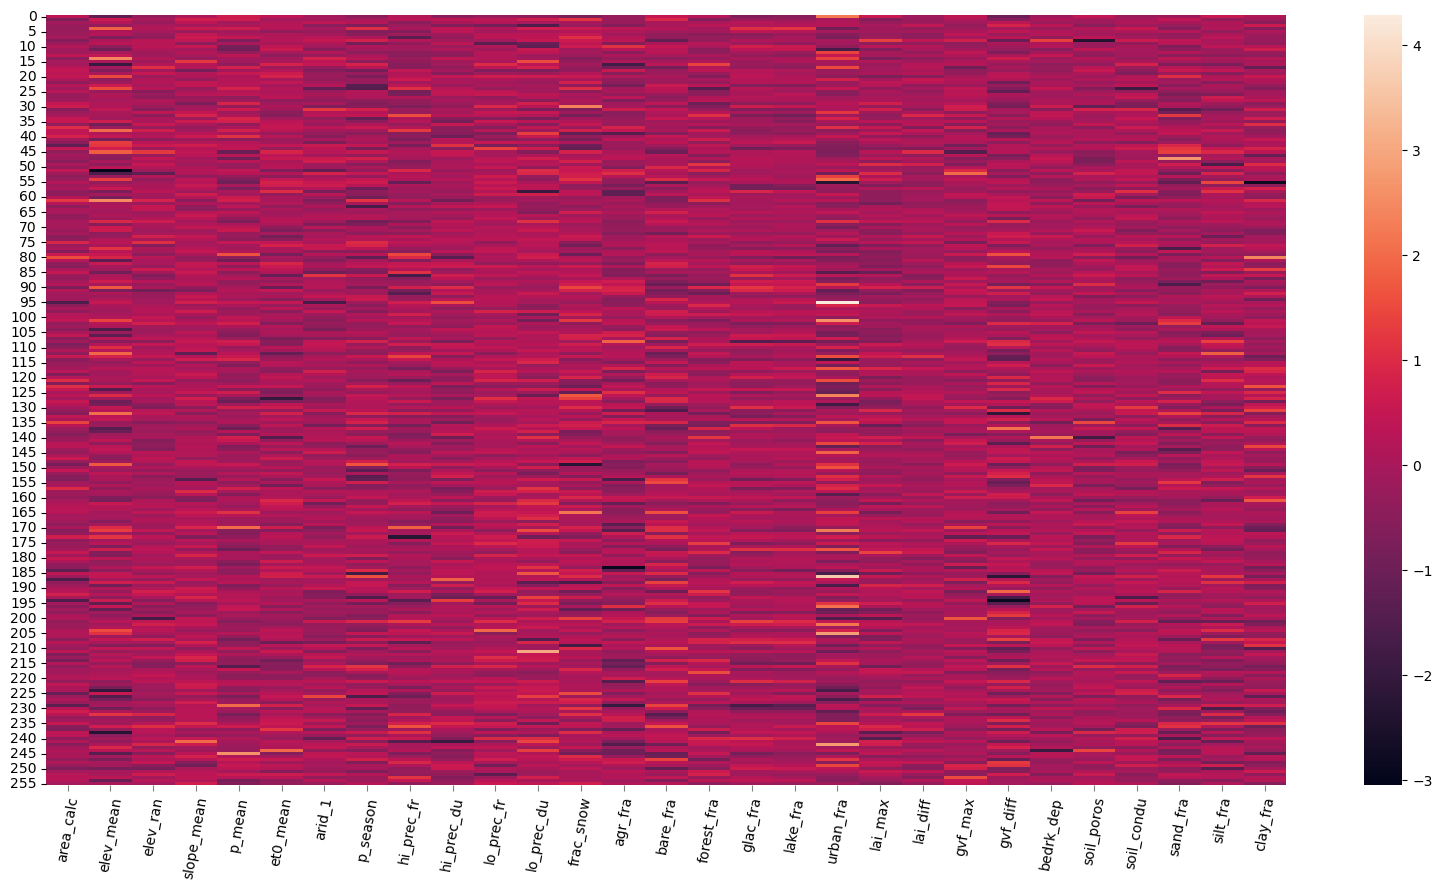

In [6]:
fig, ax = plt.subplots(1,1, figsize=(20,10))
sns.heatmap(ea_lstm.input_gate.weight.detach().numpy(), ax=ax)
ax.set_xticklabels(attributes)
ax.tick_params(axis='x', length=4, color="gray", labelrotation=80) 
    

In [25]:
scaler = load_scaler(run_dir=run_dir)
tester = get_tester(cfg=cfg, run_dir=run_dir, period="test",init_model=True)


In [26]:
tester.evaluate(epoch=16, save_results=False, metrics=["NSE"])

# Evaluation: 100%|██████████| 87/87 [02:45<00:00,  1.91s/it]


{'11': {'1D': {'xr': <xarray.Dataset> Size: 228kB
   Dimensions:    (date: 14244, time_step: 1)
   Coordinates:
     * date       (date) datetime64[ns] 114kB 1981-01-01 1981-01-02 ... 2019-12-31
     * time_step  (time_step) int64 8B 0
   Data variables:
       qobs_obs   (date, time_step) float32 57kB nan nan nan nan ... nan nan nan
       qobs_sim   (date, time_step) float32 57kB nan nan nan ... 4.786 3.917 3.59,
   'NSE': -1.6152877807617188}},
 '119': {'1D': {'xr': <xarray.Dataset> Size: 228kB
   Dimensions:    (date: 14244, time_step: 1)
   Coordinates:
     * date       (date) datetime64[ns] 114kB 1981-01-01 1981-01-02 ... 2019-12-31
     * time_step  (time_step) int64 8B 0
   Data variables:
       qobs_obs   (date, time_step) float32 57kB nan nan nan nan ... nan nan nan
       qobs_sim   (date, time_step) float32 57kB nan nan nan ... 1.861 1.839 1.821,
   'NSE': 0.7234285473823547}},
 '120': {'1D': {'xr': <xarray.Dataset> Size: 228kB
   Dimensions:    (date: 14244, time_step: 1

In [43]:
import pickle as pkl

with open("/home/wuhlmann/BA/data/processed_data/evaluation/input_gate.p", "rb") as f: 
    input_gate_dict = pkl.load(f)

input_gate_dict = dict(sorted(input_gate_dict.items(), key=lambda item: int(item[0])))


In [61]:
i_vectors = []

for b in input_gate_dict.keys():

	i_vectors.append(torch.sigmoid(input_gate_dict[b].cpu()).detach().numpy())

In [66]:
import pandas as pd
import geopandas as gpd

strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]
lamah_gdf.sort_index(ascending=True, inplace=True)

<Axes: >

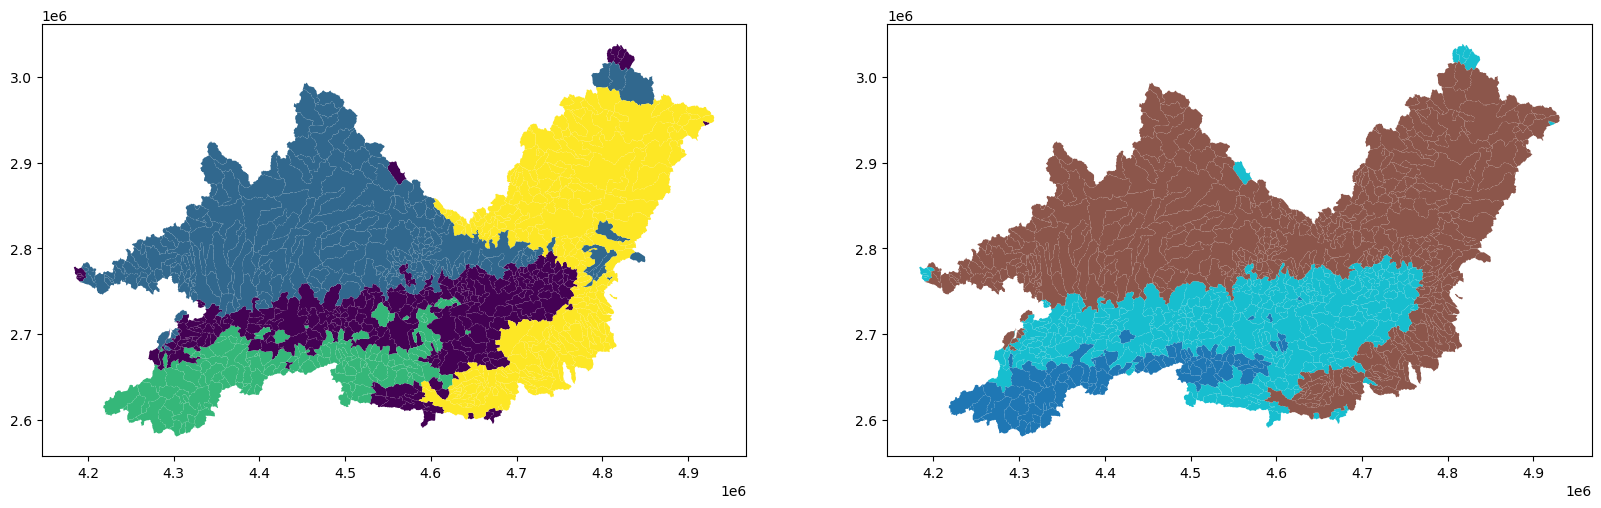

In [74]:
from sklearn.cluster import KMeans

kmeans = KMeans(4, random_state=1277)

labels = kmeans.fit_predict(i_vectors)

fig, axs = plt.subplots(1,2, figsize=(20,10))

lamah_gdf["cluster"] = labels
lamah_gdf.plot("cluster", ax=axs[0])
lamah_gdf.plot("strata", ax=axs[1])

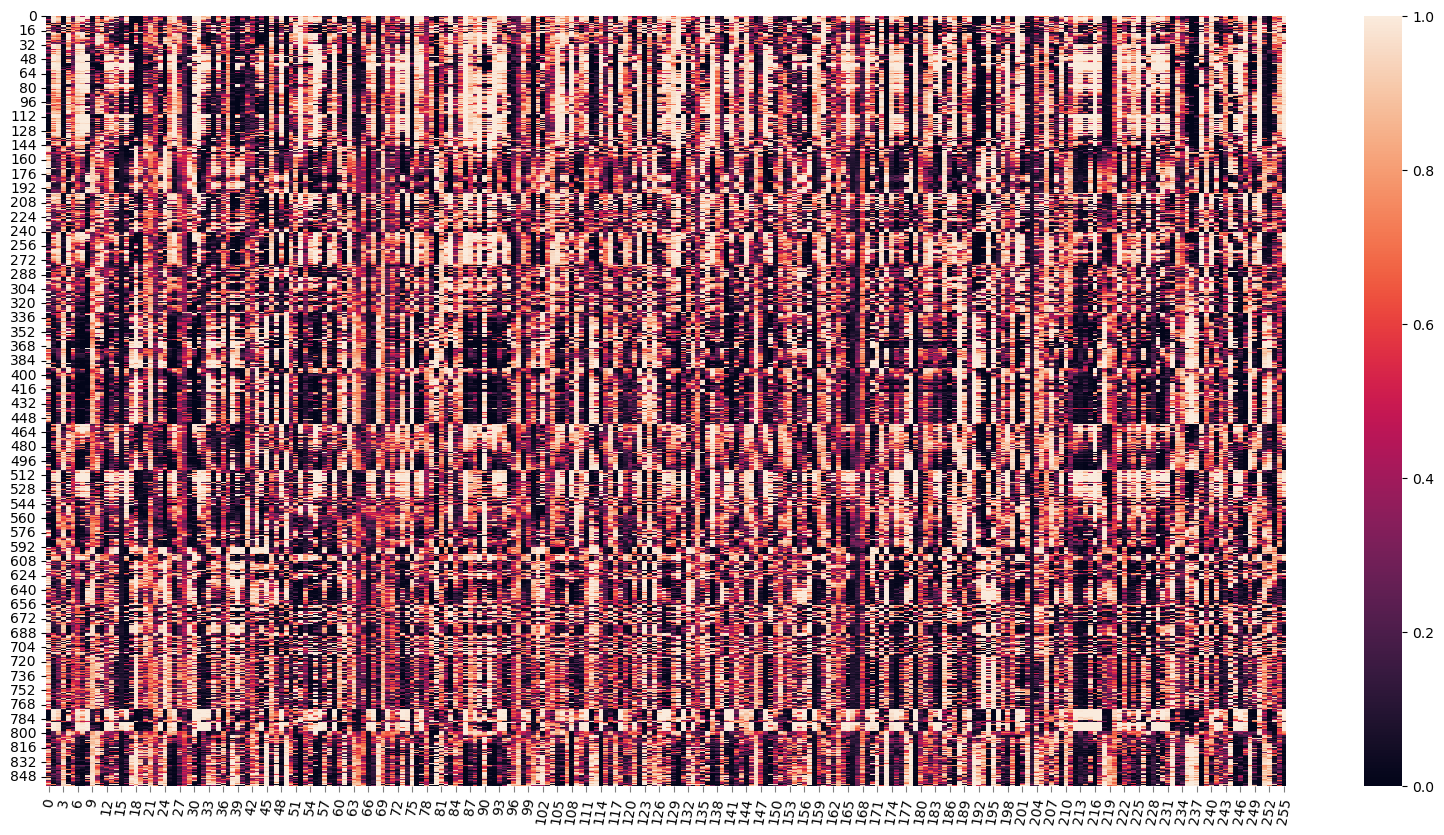

In [62]:
fig, ax = plt.subplots(1,1, figsize=(20,10))
sns.heatmap(i_vectors, ax=ax)
ax.tick_params(axis='x', length=4, color="gray", labelrotation=80) 

In [10]:
results = []
for idx, basin in enumerate(dataset.basins):
    data_batch = dataset[idx]
    print(data_batch["x_s"])
    with torch.no_grad():
        # Static inputs durch embedding layer
        x_s = ea_lstm.embedding_net(data_batch, concatenate_output=False)[1]
        
        # Input Gate Output berechnen
        i_gate = torch.sigmoid(ea_lstm.input_gate(x_s))
    
    results.append(i_gate.cpu().numpy())
    print(f"{basin}: Input gate mean = {i_gate.mean():.4f}, std = {i_gate.std():.4f}")

NameError: name 'dataset' is not defined

<Axes: >

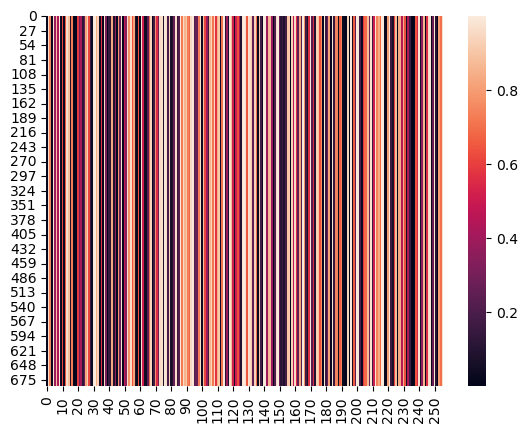

In [ ]:
sns.heatmap(results)
	